Small eval

In [12]:
# ============================================================
# EVALUATE HIERARCHICAL RULE-BASED AGENT (rule_based_grouped)
# ACROSS 500 DIFFERENT SEEDS — medium_with_margin env
# 20/40ft containers, IMO enabled, random group sizes enabled
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from envs.stack_gym import StackEnv
from agents.hierarchical_rule_based_agent import HierarchicalAgent

# ============================================================
# CONFIG
# ============================================================

config_dict = {
    "vessel_shape": (3, 3, 3),
    "yard_shape": (3, 4, 3),
    "num_containers": 27,
    "group_num": 3,
    "group_placement": "random",
    "observation_type": "flat_parsed",
    "reward_norm": False,
    "reward_clip": False,
    "stack_fill_penalty": True,
    "container_sizes": True,
    "enable_imo": True,
    "random_group_sizes": True
}

NUM_SEEDS = 500
MAX_STEPS = 500

print("=" * 70)
print("EVALUATING HIERARCHICAL RULE-BASED AGENT (rule_based_grouped)")
print("medium_with_margin | 20/40ft | IMO | random group sizes")
print(f"Seeds: {NUM_SEEDS}")
print("=" * 70)

# ============================================================
# RUN 500 EPISODES WITH DIFFERENT SEEDS
# ============================================================

all_rewards_rule = []

for seed in range(NUM_SEEDS):
    env = StackEnv(config=config_dict, render_mode=None)
    agent = HierarchicalAgent(
        vessel_shape=config_dict["vessel_shape"],
        yard_shape=config_dict["yard_shape"],
        num_slot_attrs=5,
        high_level_policy_type="rule_based_grouped",
        low_level_policy_type="rule_based_grouped",
    )

    observation, info = env.reset(seed=seed)
    total_reward = 0.0
    step_count = 0

    for _ in range(MAX_STEPS):
        valid_actions = env._get_valid_yard_actions()
        if len(valid_actions) == 0:
            break
        try:
            action, _ = agent.get_action(observation, valid_actions)
            if action is None:
                break
        except Exception:
            break

        observation, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        step_count += 1

        if terminated or truncated:
            break

    all_rewards_rule.append(total_reward)
    env.close()

    if (seed + 1) % 100 == 0:
        print(f"Completed {seed + 1}/{NUM_SEEDS} seeds...")

# ============================================================
# EVALUATE JOINT HIERARCHICAL MODEL (bay + stack trained together)
# ACROSS 500 DIFFERENT SEEDS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.joint_hierarchical_policy import MaskableJointTransformerPolicy  # or MaskableJointMlpPolicy

from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
    "vessel_shape": (3, 3, 3),
    "yard_shape": (3, 4, 3),
    "num_containers": 27,
    "group_num": 3,
    "group_placement": "random",
    "observation_type": "stack_features_v3",
    "reward_norm": False,
    "stack_fill_penalty": True,
    "container_sizes": True,
    "enable_imo": True
}

JOINT_MODEL_PATH = "models/hierarchical/pointer/small/seed1/hrl_pointer_small_seed1/best_model"
# ============================================================
# LOAD MODEL
# ============================================================

model = MaskablePPO.load(
    JOINT_MODEL_PATH,
    custom_objects={"policy_class": MaskableJointTransformerPolicy},  # or MaskableJointMlpPolicy
)

print("=" * 70)
print("EVALUATING JOINT HIERARCHICAL RL MODEL ACROSS 500 SEEDS")
print("=" * 70)

# ============================================================
# RUN 500 EPISODES WITH DIFFERENT SEEDS
# ============================================================

steps = config_dict["num_containers"]
num_seeds = 500
all_rewards_per_step = np.zeros((num_seeds, steps))
all_rewards_hrl = []

for seed in range(num_seeds):
    eval_env = StackEnv(config=config_dict, render_mode=None)
    eval_env = ActionMasker(eval_env, mask_fn)

    obs, info = eval_env.reset(seed=seed)
    terminated = False
    truncated = False
    total_reward = 0.0
    step_count = 0

    while not (terminated or truncated) and step_count < 500:
        action, _ = model.predict(
            obs,
            deterministic=True,
            action_masks=get_action_masks(eval_env),
        )
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        step_count += 1
        all_rewards_per_step[seed, step_count - 1] = reward

    all_rewards_hrl.append(total_reward)
    eval_env.close()

    if (seed + 1) % 100 == 0:
        print(f"Completed {seed + 1}/{num_seeds} seeds...")

config_dict = {
    "vessel_shape": (3, 3, 3),
    "yard_shape": (3, 4, 3),
    "num_containers": 27,
    "group_num": 3,
    "group_placement": "random",
    "observation_type": "stack_features_v3",
    "reward_norm": False,
    "stack_fill_penalty": True,
    "container_sizes": True,
    "enable_imo": True
}

JOINT_MODEL_PATH = "models/flat/pointer/small/seed1/flat_pointer_small_seed1/best_model"
# ============================================================
# LOAD MODEL
# ============================================================

model = MaskablePPO.load(
    JOINT_MODEL_PATH)

print("=" * 70)
print("EVALUATING JOINT HIERARCHICAL RL MODEL ACROSS 500 SEEDS")
print("=" * 70)

# ============================================================
# RUN 500 EPISODES WITH DIFFERENT SEEDS
# ============================================================

steps = config_dict["num_containers"]
num_seeds = 500
all_rewards_per_step = np.zeros((num_seeds, steps))
all_rewards_flatrl = []

for seed in range(num_seeds):
    eval_env = StackEnv(config=config_dict, render_mode=None)
    eval_env = ActionMasker(eval_env, mask_fn)

    obs, info = eval_env.reset(seed=seed)
    terminated = False
    truncated = False
    total_reward = 0.0
    step_count = 0

    while not (terminated or truncated) and step_count < 500:
        action, _ = model.predict(
            obs,
            deterministic=True,
            action_masks=get_action_masks(eval_env),
        )
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        step_count += 1
        all_rewards_per_step[seed, step_count - 1] = reward

    all_rewards_flatrl.append(total_reward)
    eval_env.close()

    if (seed + 1) % 100 == 0:
        print(f"Completed {seed + 1}/{num_seeds} seeds...")




EVALUATING HIERARCHICAL RULE-BASED AGENT (rule_based_grouped)
medium_with_margin | 20/40ft | IMO | random group sizes
Seeds: 500
Completed 100/500 seeds...
Completed 200/500 seeds...
Completed 300/500 seeds...
Completed 400/500 seeds...
Completed 500/500 seeds...
EVALUATING JOINT HIERARCHICAL RL MODEL ACROSS 500 SEEDS
Completed 100/500 seeds...
Completed 200/500 seeds...
Completed 300/500 seeds...
Completed 400/500 seeds...
Completed 500/500 seeds...
EVALUATING JOINT HIERARCHICAL RL MODEL ACROSS 500 SEEDS
Completed 100/500 seeds...
Completed 200/500 seeds...
Completed 300/500 seeds...
Completed 400/500 seeds...
Completed 500/500 seeds...


In [13]:
threshold = 90

print("Statistics for Hierarchical Rule-Based Agent:")
all_rewards_rule = np.array(all_rewards_rule)
mean_reward_rule = np.mean(all_rewards_rule)
std_reward_rule  = np.std(all_rewards_rule)
min_reward_rule  = np.min(all_rewards_rule)
max_reward_rule  = np.max(all_rewards_rule)

percent_max = np.sum(all_rewards_rule > threshold) / num_seeds * 100

print(f"Seed with highest reward: {np.argmax(all_rewards_rule)} with reward {max_reward_rule:.2f}")
print(f"Seed with lowest reward:  {np.argmin(all_rewards_rule)} with reward {min_reward_rule:.2f}")
print("\n" + "=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"Mean Reward: {mean_reward_rule:.4f}")
print(f"Std Reward:  {std_reward_rule:.4f}")
print(f"Min Reward:  {min_reward_rule:.4f}")
print(f"Max Reward:  {max_reward_rule:.4f}")
print(f"% seeds achieving max reward: {percent_max:.2f}%")
print("=" * 70)

print ("\n\nStatistics for Joint Hierarchical RL Agent:")
all_rewards_hrl = np.array(all_rewards_hrl)
mean_reward_hrl = np.mean(all_rewards_hrl)
std_reward_hrl  = np.std(all_rewards_hrl)
min_reward_hrl  = np.min(all_rewards_hrl)
max_reward_hrl  = np.max(all_rewards_hrl)
percent_max_hrl = np.sum(all_rewards_hrl > threshold) / num_seeds * 100

print(f"Seed with highest reward: {np.argmax(all_rewards_hrl)} with reward {max_reward_hrl:.2f}")
print(f"Seed with lowest reward:  {np.argmin(all_rewards_hrl)} with reward {min_reward_hrl:.2f}")
print("\n" + "=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"Mean Reward: {mean_reward_hrl:.4f}")
print(f"Std Reward:  {std_reward_hrl:.4f}")
print(f"Min Reward:  {min_reward_hrl:.4f}")
print(f"Max Reward:  {max_reward_hrl:.4f}")
print(f"% seeds achieving max reward: {percent_max_hrl:.2f}%")
print("=" * 70)

print ("\n\nStatistics for Flat RL Agent:")
all_rewards_flatrl = np.array(all_rewards_flatrl)
mean_reward_flatrl = np.mean(all_rewards_flatrl)
std_reward_flatrl  = np.std(all_rewards_flatrl)
min_reward_flatrl  = np.min(all_rewards_flatrl)
max_reward_flatrl  = np.max(all_rewards_flatrl)

percent_max_flatrl = np.sum(all_rewards_flatrl > threshold) / num_seeds * 100
print(f"Seed with highest reward: {np.argmax(all_rewards_flatrl)} with reward {max_reward_flatrl:.2f}")
print(f"Seed with lowest reward:  {np.argmin(all_rewards_flatrl)} with reward {min_reward_flatrl:.2f}")
print("\n" + "=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"Mean Reward: {mean_reward_flatrl:.4f}")
print(f"Std Reward:  {std_reward_flatrl:.4f}")
print(f"Min Reward:  {min_reward_flatrl:.4f}")
print(f"Max Reward:  {max_reward_flatrl:.4f}")
print(f"% seeds achieving max reward: {percent_max_flatrl:.2f}%")
print("=" * 70)



Statistics for Hierarchical Rule-Based Agent:
Seed with highest reward: 436 with reward 115.20
Seed with lowest reward:  75 with reward 43.80

EVALUATION RESULTS
Mean Reward: 91.6240
Std Reward:  7.9285
Min Reward:  43.8000
Max Reward:  115.2000
% seeds achieving max reward: 65.40%


Statistics for Joint Hierarchical RL Agent:
Seed with highest reward: 200 with reward 102.60
Seed with lowest reward:  151 with reward 42.40

EVALUATION RESULTS
Mean Reward: 96.5876
Std Reward:  5.2606
Min Reward:  42.4000
Max Reward:  102.6000
% seeds achieving max reward: 97.80%


Statistics for Flat RL Agent:
Seed with highest reward: 148 with reward 102.60
Seed with lowest reward:  308 with reward 80.20

EVALUATION RESULTS
Mean Reward: 98.2824
Std Reward:  3.2048
Min Reward:  80.2000
Max Reward:  102.6000
% seeds achieving max reward: 97.20%


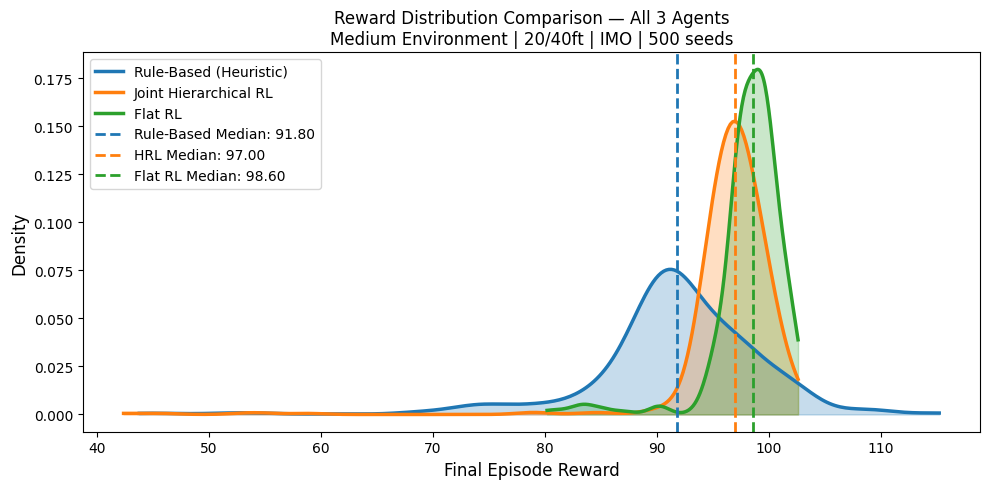

In [15]:
# ============================================================
# COMBINED KDE PLOT - ALL 3 AGENTS
# ============================================================

# Calculate medians
p50_rule = np.percentile(all_rewards_rule, 50)
p50_hrl = np.percentile(all_rewards_hrl, 50)
p50_flatrl = np.percentile(all_rewards_flatrl, 50)

# Create plot
plt.figure(figsize=(10, 5))

# Colors for each agent
colors = {
    'rule': '#1f77b4',      # blue
    'hrl': '#ff7f0e',       # orange
    'flatrl': '#2ca02c'     # green
}

# Plot KDE for Rule-Based Agent
density_rule = gaussian_kde(all_rewards_rule)
xs_rule = np.linspace(all_rewards_rule.min(), all_rewards_rule.max(), 300)
ys_rule = density_rule(xs_rule)
plt.fill_between(xs_rule, ys_rule, alpha=0.25, color=colors['rule'])
plt.plot(xs_rule, ys_rule, linewidth=2.5, color=colors['rule'], label='Rule-Based (Heuristic)')

# Plot KDE for HRL Agent
density_hrl = gaussian_kde(all_rewards_hrl)
xs_hrl = np.linspace(all_rewards_hrl.min(), all_rewards_hrl.max(), 300)
ys_hrl = density_hrl(xs_hrl)
plt.fill_between(xs_hrl, ys_hrl, alpha=0.25, color=colors['hrl'])
plt.plot(xs_hrl, ys_hrl, linewidth=2.5, color=colors['hrl'], label='Joint Hierarchical RL')

# Plot KDE for Flat RL Agent
density_flatrl = gaussian_kde(all_rewards_flatrl)
xs_flatrl = np.linspace(all_rewards_flatrl.min(), all_rewards_flatrl.max(), 300)
ys_flatrl = density_flatrl(xs_flatrl)
plt.fill_between(xs_flatrl, ys_flatrl, alpha=0.25, color=colors['flatrl'])
plt.plot(xs_flatrl, ys_flatrl, linewidth=2.5, color=colors['flatrl'], label='Flat RL')

# Plot medians
plt.axvline(p50_rule, color=colors['rule'], linestyle='--', linewidth=2, label=f'Rule-Based Median: {p50_rule:.2f}')
plt.axvline(p50_hrl, color=colors['hrl'], linestyle='--', linewidth=2, label=f'HRL Median: {p50_hrl:.2f}')
plt.axvline(p50_flatrl, color=colors['flatrl'], linestyle='--', linewidth=2, label=f'Flat RL Median: {p50_flatrl:.2f}')

plt.legend(fontsize=10, loc='best')
plt.xlabel("Final Episode Reward", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title(
    f"Reward Distribution Comparison — All 3 Agents\n"
    f"Medium Environment | 20/40ft | IMO | {num_seeds} seeds"
)
plt.tight_layout()
plt.show()

Medium eval

In [1]:
# ============================================================
# EVALUATE HIERARCHICAL RULE-BASED AGENT (rule_based_grouped)
# ACROSS 500 DIFFERENT SEEDS — medium_with_margin env
# 20/40ft containers, IMO enabled, random group sizes enabled
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from envs.stack_gym import StackEnv
from agents.hierarchical_rule_based_agent import HierarchicalAgent

# ============================================================
# CONFIG
# ============================================================

config_dict = {
    "vessel_shape": (4, 4, 4),
    "yard_shape": (4, 5, 4),
    "num_containers": 64,
    "group_num": 4,
    "group_placement": "random",
    "observation_type": "flat_parsed",
    "reward_norm": False,
    "reward_clip": False,
    "stack_fill_penalty": True,
    "container_sizes": True,
    "enable_imo": True,
    "random_group_sizes": True
}

NUM_SEEDS = 500
MAX_STEPS = 500

print("=" * 70)
print("EVALUATING HIERARCHICAL RULE-BASED AGENT (rule_based_grouped)")
print("medium_with_margin | 20/40ft | IMO | random group sizes")
print(f"Seeds: {NUM_SEEDS}")
print("=" * 70)

# ============================================================
# RUN 500 EPISODES WITH DIFFERENT SEEDS
# ============================================================

all_rewards_rule = []

for seed in range(NUM_SEEDS):
    env = StackEnv(config=config_dict, render_mode=None)
    agent = HierarchicalAgent(
        vessel_shape=config_dict["vessel_shape"],
        yard_shape=config_dict["yard_shape"],
        num_slot_attrs=5,
        high_level_policy_type="rule_based_grouped",
        low_level_policy_type="rule_based_grouped",
    )

    observation, info = env.reset(seed=seed)
    total_reward = 0.0
    step_count = 0

    for _ in range(MAX_STEPS):
        valid_actions = env._get_valid_yard_actions()
        if len(valid_actions) == 0:
            break
        try:
            action, _ = agent.get_action(observation, valid_actions)
            if action is None:
                break
        except Exception:
            break

        observation, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        step_count += 1

        if terminated or truncated:
            break

    all_rewards_rule.append(total_reward)
    env.close()

    if (seed + 1) % 100 == 0:
        print(f"Completed {seed + 1}/{NUM_SEEDS} seeds...")

# ============================================================
# EVALUATE JOINT HIERARCHICAL MODEL (bay + stack trained together)
# ACROSS 500 DIFFERENT SEEDS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.joint_hierarchical_policy import MaskableJointTransformerPolicy  # or MaskableJointMlpPolicy

from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
    "vessel_shape": (4, 4, 4),
    "yard_shape": (4, 5, 4),
    "num_containers": 64,
    "group_num": 4,
    "group_placement": "random",
    "observation_type": "stack_features_v3",
    "reward_norm": False,
    "stack_fill_penalty": True,
    "container_sizes": True,
    "enable_imo": True
}

JOINT_MODEL_PATH = "models/hierarchical/pointer/medium/seed1/hrl_pointer_medium_seed1/best_model"
# ============================================================
# LOAD MODEL
# ============================================================

model = MaskablePPO.load(
    JOINT_MODEL_PATH,
    custom_objects={"policy_class": MaskableJointTransformerPolicy},  # or MaskableJointMlpPolicy
)

print("=" * 70)
print("EVALUATING JOINT HIERARCHICAL RL MODEL ACROSS 500 SEEDS")
print("=" * 70)

# ============================================================
# RUN 500 EPISODES WITH DIFFERENT SEEDS
# ============================================================

steps = config_dict["num_containers"]
num_seeds = 500
all_rewards_per_step = np.zeros((num_seeds, steps))
all_rewards_hrl = []

for seed in range(num_seeds):
    eval_env = StackEnv(config=config_dict, render_mode=None)
    eval_env = ActionMasker(eval_env, mask_fn)

    obs, info = eval_env.reset(seed=seed)
    terminated = False
    truncated = False
    total_reward = 0.0
    step_count = 0

    while not (terminated or truncated) and step_count < 500:
        action, _ = model.predict(
            obs,
            deterministic=True,
            action_masks=get_action_masks(eval_env),
        )
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        step_count += 1
        all_rewards_per_step[seed, step_count - 1] = reward

    all_rewards_hrl.append(total_reward)
    eval_env.close()

    if (seed + 1) % 100 == 0:
        print(f"Completed {seed + 1}/{num_seeds} seeds...")

config_dict = {
    "vessel_shape": (4, 4, 4),
    "yard_shape": (4, 5, 4),
    "num_containers": 64,
    "group_num": 4,
    "group_placement": "random",
    "observation_type": "stack_features_v3",
    "reward_norm": False,
    "stack_fill_penalty": True,
    "container_sizes": True,
    "enable_imo": True
}

FLAT_MODEL_PATH = "models/flat/pointer/medium/seed1/flat_pointer_medium_seed1/best_model"
# ============================================================
# LOAD MODEL
# ============================================================

model = MaskablePPO.load(
    FLAT_MODEL_PATH)

print("=" * 70)
print("EVALUATING FLAT RL MODEL ACROSS 500 SEEDS")
print("=" * 70)

# ============================================================
# RUN 500 EPISODES WITH DIFFERENT SEEDS
# ============================================================

steps = config_dict["num_containers"]
num_seeds = 500
all_rewards_per_step = np.zeros((num_seeds, steps))
all_rewards_flatrl = []

for seed in range(num_seeds):
    eval_env = StackEnv(config=config_dict, render_mode=None)
    eval_env = ActionMasker(eval_env, mask_fn)

    obs, info = eval_env.reset(seed=seed)
    terminated = False
    truncated = False
    total_reward = 0.0
    step_count = 0

    while not (terminated or truncated) and step_count < 500:
        action, _ = model.predict(
            obs,
            deterministic=True,
            action_masks=get_action_masks(eval_env),
        )
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        step_count += 1
        all_rewards_per_step[seed, step_count - 1] = reward

    all_rewards_flatrl.append(total_reward)
    eval_env.close()

    if (seed + 1) % 100 == 0:
        print(f"Completed {seed + 1}/{num_seeds} seeds...")




EVALUATING HIERARCHICAL RULE-BASED AGENT (rule_based_grouped)
medium_with_margin | 20/40ft | IMO | random group sizes
Seeds: 500
Completed 100/500 seeds...
Completed 200/500 seeds...
Completed 300/500 seeds...
Completed 400/500 seeds...
Completed 500/500 seeds...
EVALUATING JOINT HIERARCHICAL RL MODEL ACROSS 500 SEEDS
Completed 100/500 seeds...
Completed 200/500 seeds...
Completed 300/500 seeds...
Completed 400/500 seeds...
Completed 500/500 seeds...
EVALUATING FLAT RL MODEL ACROSS 500 SEEDS
Completed 100/500 seeds...
Completed 200/500 seeds...
Completed 300/500 seeds...
Completed 400/500 seeds...
Completed 500/500 seeds...


In [4]:
threshold = 360

print("Statistics for Hierarchical Rule-Based Agent:")
all_rewards_rule = np.array(all_rewards_rule)
mean_reward_rule = np.mean(all_rewards_rule)
std_reward_rule  = np.std(all_rewards_rule)
min_reward_rule  = np.min(all_rewards_rule)
max_reward_rule  = np.max(all_rewards_rule)

percent_max = np.sum(all_rewards_rule > threshold) / num_seeds * 100

print(f"Seed with highest reward: {np.argmax(all_rewards_rule)} with reward {max_reward_rule:.2f}")
print(f"Seed with lowest reward:  {np.argmin(all_rewards_rule)} with reward {min_reward_rule:.2f}")
print("\n" + "=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"Mean Reward: {mean_reward_rule:.4f}")
print(f"Std Reward:  {std_reward_rule:.4f}")
print(f"Min Reward:  {min_reward_rule:.4f}")
print(f"Max Reward:  {max_reward_rule:.4f}")
print(f"% seeds achieving max reward: {percent_max:.2f}%")
print("=" * 70)

print ("\n\nStatistics for Joint Hierarchical RL Agent:")
all_rewards_hrl = np.array(all_rewards_hrl)
mean_reward_hrl = np.mean(all_rewards_hrl)
std_reward_hrl  = np.std(all_rewards_hrl)
min_reward_hrl  = np.min(all_rewards_hrl)
max_reward_hrl  = np.max(all_rewards_hrl)
percent_max_hrl = np.sum(all_rewards_hrl > threshold) / num_seeds * 100

print(f"Seed with highest reward: {np.argmax(all_rewards_hrl)} with reward {max_reward_hrl:.2f}")
print(f"Seed with lowest reward:  {np.argmin(all_rewards_hrl)} with reward {min_reward_hrl:.2f}")
print("\n" + "=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"Mean Reward: {mean_reward_hrl:.4f}")
print(f"Std Reward:  {std_reward_hrl:.4f}")
print(f"Min Reward:  {min_reward_hrl:.4f}")
print(f"Max Reward:  {max_reward_hrl:.4f}")
print(f"% seeds achieving max reward: {percent_max_hrl:.2f}%")
print("=" * 70)

print ("\n\nStatistics for Flat RL Agent:")
all_rewards_flatrl = np.array(all_rewards_flatrl)
mean_reward_flatrl = np.mean(all_rewards_flatrl)
std_reward_flatrl  = np.std(all_rewards_flatrl)
min_reward_flatrl  = np.min(all_rewards_flatrl)
max_reward_flatrl  = np.max(all_rewards_flatrl)

percent_max_flatrl = np.sum(all_rewards_flatrl > threshold) / num_seeds * 100
print(f"Seed with highest reward: {np.argmax(all_rewards_flatrl)} with reward {max_reward_flatrl:.2f}")
print(f"Seed with lowest reward:  {np.argmin(all_rewards_flatrl)} with reward {min_reward_flatrl:.2f}")
print("\n" + "=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"Mean Reward: {mean_reward_flatrl:.4f}")
print(f"Std Reward:  {std_reward_flatrl:.4f}")
print(f"Min Reward:  {min_reward_flatrl:.4f}")
print(f"Max Reward:  {max_reward_flatrl:.4f}")
print(f"% seeds achieving max reward: {percent_max_flatrl:.2f}%")
print("=" * 70)



Statistics for Hierarchical Rule-Based Agent:
Seed with highest reward: 307 with reward 371.20
Seed with lowest reward:  172 with reward 240.80

EVALUATION RESULTS
Mean Reward: 327.8116
Std Reward:  24.7275
Min Reward:  240.8000
Max Reward:  371.2000
% seeds achieving max reward: 7.80%


Statistics for Joint Hierarchical RL Agent:
Seed with highest reward: 125 with reward 422.40
Seed with lowest reward:  9 with reward 377.00

EVALUATION RESULTS
Mean Reward: 406.4124
Std Reward:  3.9041
Min Reward:  377.0000
Max Reward:  422.4000
% seeds achieving max reward: 100.00%


Statistics for Flat RL Agent:
Seed with highest reward: 482 with reward 316.80
Seed with lowest reward:  206 with reward 37.40

EVALUATION RESULTS
Mean Reward: 178.1052
Std Reward:  31.3711
Min Reward:  37.4000
Max Reward:  316.8000
% seeds achieving max reward: 0.00%


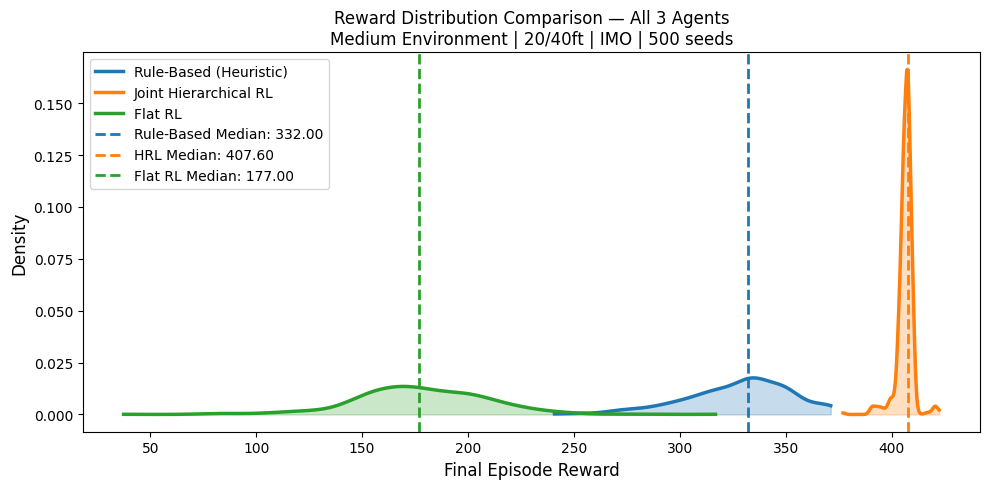

In [6]:
# ============================================================
# COMBINED KDE PLOT - ALL 3 AGENTS
# ============================================================

# Calculate medians
p50_rule = np.percentile(all_rewards_rule, 50)
p50_hrl = np.percentile(all_rewards_hrl, 50)
p50_flatrl = np.percentile(all_rewards_flatrl, 50)

# Create plot
plt.figure(figsize=(10, 5))

# Colors for each agent
colors = {
    'rule': '#1f77b4',      # blue
    'hrl': '#ff7f0e',       # orange
    'flatrl': '#2ca02c'     # green
}

# Plot KDE for Rule-Based Agent
density_rule = gaussian_kde(all_rewards_rule)
xs_rule = np.linspace(all_rewards_rule.min(), all_rewards_rule.max(), 300)
ys_rule = density_rule(xs_rule)
plt.fill_between(xs_rule, ys_rule, alpha=0.25, color=colors['rule'])
plt.plot(xs_rule, ys_rule, linewidth=2.5, color=colors['rule'], label='Rule-Based (Heuristic)')

# Plot KDE for HRL Agent
density_hrl = gaussian_kde(all_rewards_hrl)
xs_hrl = np.linspace(all_rewards_hrl.min(), all_rewards_hrl.max(), 300)
ys_hrl = density_hrl(xs_hrl)
plt.fill_between(xs_hrl, ys_hrl, alpha=0.25, color=colors['hrl'])
plt.plot(xs_hrl, ys_hrl, linewidth=2.5, color=colors['hrl'], label='Joint Hierarchical RL')

# Plot KDE for Flat RL Agent
density_flatrl = gaussian_kde(all_rewards_flatrl)
xs_flatrl = np.linspace(all_rewards_flatrl.min(), all_rewards_flatrl.max(), 300)
ys_flatrl = density_flatrl(xs_flatrl)
plt.fill_between(xs_flatrl, ys_flatrl, alpha=0.25, color=colors['flatrl'])
plt.plot(xs_flatrl, ys_flatrl, linewidth=2.5, color=colors['flatrl'], label='Flat RL')

# Plot medians
plt.axvline(p50_rule, color=colors['rule'], linestyle='--', linewidth=2, label=f'Rule-Based Median: {p50_rule:.2f}')
plt.axvline(p50_hrl, color=colors['hrl'], linestyle='--', linewidth=2, label=f'HRL Median: {p50_hrl:.2f}')
plt.axvline(p50_flatrl, color=colors['flatrl'], linestyle='--', linewidth=2, label=f'Flat RL Median: {p50_flatrl:.2f}')

plt.legend(fontsize=10, loc='best')
plt.xlabel("Final Episode Reward", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title(
    f"Reward Distribution Comparison — All 3 Agents\n"
    f"Medium Environment | 20/40ft | IMO | {num_seeds} seeds"
)
plt.tight_layout()
plt.show()

Eval Large

In [ ]:
# ============================================================
# EVALUATE HIERARCHICAL RULE-BASED AGENT (rule_based_grouped)
# ACROSS 500 DIFFERENT SEEDS — medium_with_margin env
# 20/40ft containers, IMO enabled, random group sizes enabled
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from envs.stack_gym import StackEnv
from agents.hierarchical_rule_based_agent import HierarchicalAgent

# ============================================================
# CONFIG
# ============================================================

config_dict = {
    "vessel_shape": (6, 6, 5),
    "yard_shape": (6, 7, 5),
    "num_containers": 180,
    "group_num": 6,
    "group_placement": "random",
    "observation_type": "flat_parsed",
    "reward_norm": False,
    "reward_clip": False,
    "stack_fill_penalty": True,
    "container_sizes": True,
    "enable_imo": True,
    "random_group_sizes": True
}

NUM_SEEDS = 500
MAX_STEPS = 500

print("=" * 70)
print("EVALUATING HIERARCHICAL RULE-BASED AGENT (rule_based_grouped)")
print("medium_with_margin | 20/40ft | IMO | random group sizes")
print(f"Seeds: {NUM_SEEDS}")
print("=" * 70)

# ============================================================
# RUN 500 EPISODES WITH DIFFERENT SEEDS
# ============================================================

all_rewards_rule = []

for seed in range(NUM_SEEDS):
    env = StackEnv(config=config_dict, render_mode=None)
    agent = HierarchicalAgent(
        vessel_shape=config_dict["vessel_shape"],
        yard_shape=config_dict["yard_shape"],
        num_slot_attrs=5,
        high_level_policy_type="rule_based_grouped",
        low_level_policy_type="rule_based_grouped",
    )

    observation, info = env.reset(seed=seed)
    total_reward = 0.0
    step_count = 0

    for _ in range(MAX_STEPS):
        valid_actions = env._get_valid_yard_actions()
        if len(valid_actions) == 0:
            break
        try:
            action, _ = agent.get_action(observation, valid_actions)
            if action is None:
                break
        except Exception:
            break

        observation, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        step_count += 1

        if terminated or truncated:
            break

    all_rewards_rule.append(total_reward)
    env.close()

    if (seed + 1) % 100 == 0:
        print(f"Completed {seed + 1}/{NUM_SEEDS} seeds...")

# ============================================================
# EVALUATE JOINT HIERARCHICAL MODEL (bay + stack trained together)
# ACROSS 500 DIFFERENT SEEDS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.joint_hierarchical_policy import MaskableJointTransformerPolicy  # or MaskableJointMlpPolicy

from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
    "vessel_shape": (6, 6, 5),
    "yard_shape": (6, 7, 5),
    "num_containers": 180,
    "group_num": 6,
    "group_placement": "random",
    "observation_type": "stack_features_v3",
    "reward_norm": False,
    "stack_fill_penalty": True,
    "container_sizes": True,
    "enable_imo": True
}

JOINT_MODEL_PATH = "models/hierarchical/pointer/large1/seed1/hrl_pointer_large1_seed1/best_model"
# ============================================================
# LOAD MODEL
# ============================================================

model = MaskablePPO.load(
    JOINT_MODEL_PATH,
    custom_objects={"policy_class": MaskableJointTransformerPolicy},  # or MaskableJointMlpPolicy
)

print("=" * 70)
print("EVALUATING JOINT HIERARCHICAL RL MODEL ACROSS 500 SEEDS")
print("=" * 70)

# ============================================================
# RUN 500 EPISODES WITH DIFFERENT SEEDS
# ============================================================

steps = config_dict["num_containers"]
num_seeds = 500
all_rewards_per_step = np.zeros((num_seeds, steps))
all_rewards_hrl = []

for seed in range(num_seeds):
    eval_env = StackEnv(config=config_dict, render_mode=None)
    eval_env = ActionMasker(eval_env, mask_fn)

    obs, info = eval_env.reset(seed=seed)
    terminated = False
    truncated = False
    total_reward = 0.0
    step_count = 0

    while not (terminated or truncated) and step_count < 500:
        action, _ = model.predict(
            obs,
            deterministic=True,
            action_masks=get_action_masks(eval_env),
        )
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        step_count += 1
        all_rewards_per_step[seed, step_count - 1] = reward

    all_rewards_hrl.append(total_reward)
    eval_env.close()

    if (seed + 1) % 100 == 0:
        print(f"Completed {seed + 1}/{num_seeds} seeds...")

config_dict = {
    "vessel_shape": (6, 6, 5),
    "yard_shape": (6, 7, 5),
    "num_containers": 180,
    "group_num": 6,
    "group_placement": "random",
    "observation_type": "stack_features_v3",
    "reward_norm": False,
    "stack_fill_penalty": True,
    "container_sizes": True,
    "enable_imo": True
}

FLAT_MODEL_PATH = "models/flat/pointer/large1/seed1/flat_pointer_large1_seed1/best_model"
# ============================================================
# LOAD MODEL
# ============================================================

model = MaskablePPO.load(
    FLAT_MODEL_PATH)

print("=" * 70)
print("EVALUATING FLAT RL MODEL ACROSS 500 SEEDS")
print("=" * 70)

# ============================================================
# RUN 500 EPISODES WITH DIFFERENT SEEDS
# ============================================================

steps = config_dict["num_containers"]
num_seeds = 500
all_rewards_per_step = np.zeros((num_seeds, steps))
all_rewards_flatrl = []

for seed in range(num_seeds):
    eval_env = StackEnv(config=config_dict, render_mode=None)
    eval_env = ActionMasker(eval_env, mask_fn)

    obs, info = eval_env.reset(seed=seed)
    terminated = False
    truncated = False
    total_reward = 0.0
    step_count = 0

    while not (terminated or truncated) and step_count < 500:
        action, _ = model.predict(
            obs,
            deterministic=True,
            action_masks=get_action_masks(eval_env),
        )
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        step_count += 1
        all_rewards_per_step[seed, step_count - 1] = reward

    all_rewards_flatrl.append(total_reward)
    eval_env.close()

    if (seed + 1) % 100 == 0:
        print(f"Completed {seed + 1}/{num_seeds} seeds...")




In [ ]:
threshold = 1580

print("Statistics for Hierarchical Rule-Based Agent:")
all_rewards_rule = np.array(all_rewards_rule)
mean_reward_rule = np.mean(all_rewards_rule)
std_reward_rule  = np.std(all_rewards_rule)
min_reward_rule  = np.min(all_rewards_rule)
max_reward_rule  = np.max(all_rewards_rule)

percent_max = np.sum(all_rewards_rule > threshold) / num_seeds * 100

print(f"Seed with highest reward: {np.argmax(all_rewards_rule)} with reward {max_reward_rule:.2f}")
print(f"Seed with lowest reward:  {np.argmin(all_rewards_rule)} with reward {min_reward_rule:.2f}")
print("\n" + "=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"Mean Reward: {mean_reward_rule:.4f}")
print(f"Std Reward:  {std_reward_rule:.4f}")
print(f"Min Reward:  {min_reward_rule:.4f}")
print(f"Max Reward:  {max_reward_rule:.4f}")
print(f"% seeds achieving max reward: {percent_max:.2f}%")
print("=" * 70)

print ("\n\nStatistics for Joint Hierarchical RL Agent:")
all_rewards_hrl = np.array(all_rewards_hrl)
mean_reward_hrl = np.mean(all_rewards_hrl)
std_reward_hrl  = np.std(all_rewards_hrl)
min_reward_hrl  = np.min(all_rewards_hrl)
max_reward_hrl  = np.max(all_rewards_hrl)
percent_max_hrl = np.sum(all_rewards_hrl > threshold) / num_seeds * 100

print(f"Seed with highest reward: {np.argmax(all_rewards_hrl)} with reward {max_reward_hrl:.2f}")
print(f"Seed with lowest reward:  {np.argmin(all_rewards_hrl)} with reward {min_reward_hrl:.2f}")
print("\n" + "=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"Mean Reward: {mean_reward_hrl:.4f}")
print(f"Std Reward:  {std_reward_hrl:.4f}")
print(f"Min Reward:  {min_reward_hrl:.4f}")
print(f"Max Reward:  {max_reward_hrl:.4f}")
print(f"% seeds achieving max reward: {percent_max_hrl:.2f}%")
print("=" * 70)

print ("\n\nStatistics for Flat RL Agent:")
all_rewards_flatrl = np.array(all_rewards_flatrl)
mean_reward_flatrl = np.mean(all_rewards_flatrl)
std_reward_flatrl  = np.std(all_rewards_flatrl)
min_reward_flatrl  = np.min(all_rewards_flatrl)
max_reward_flatrl  = np.max(all_rewards_flatrl)

percent_max_flatrl = np.sum(all_rewards_flatrl > threshold) / num_seeds * 100
print(f"Seed with highest reward: {np.argmax(all_rewards_flatrl)} with reward {max_reward_flatrl:.2f}")
print(f"Seed with lowest reward:  {np.argmin(all_rewards_flatrl)} with reward {min_reward_flatrl:.2f}")
print("\n" + "=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"Mean Reward: {mean_reward_flatrl:.4f}")
print(f"Std Reward:  {std_reward_flatrl:.4f}")
print(f"Min Reward:  {min_reward_flatrl:.4f}")
print(f"Max Reward:  {max_reward_flatrl:.4f}")
print(f"% seeds achieving max reward: {percent_max_flatrl:.2f}%")
print("=" * 70)



In [ ]:
# ============================================================
# COMBINED KDE PLOT - ALL 3 AGENTS
# ============================================================

# Calculate medians
p50_rule = np.percentile(all_rewards_rule, 50)
p50_hrl = np.percentile(all_rewards_hrl, 50)
p50_flatrl = np.percentile(all_rewards_flatrl, 50)

# Create plot
plt.figure(figsize=(10, 5))

# Colors for each agent
colors = {
    'rule': '#1f77b4',      # blue
    'hrl': '#ff7f0e',       # orange
    'flatrl': '#2ca02c'     # green
}

# Plot KDE for Rule-Based Agent
density_rule = gaussian_kde(all_rewards_rule)
xs_rule = np.linspace(all_rewards_rule.min(), all_rewards_rule.max(), 300)
ys_rule = density_rule(xs_rule)
plt.fill_between(xs_rule, ys_rule, alpha=0.25, color=colors['rule'])
plt.plot(xs_rule, ys_rule, linewidth=2.5, color=colors['rule'], label='Rule-Based (Heuristic)')

# Plot KDE for HRL Agent
density_hrl = gaussian_kde(all_rewards_hrl)
xs_hrl = np.linspace(all_rewards_hrl.min(), all_rewards_hrl.max(), 300)
ys_hrl = density_hrl(xs_hrl)
plt.fill_between(xs_hrl, ys_hrl, alpha=0.25, color=colors['hrl'])
plt.plot(xs_hrl, ys_hrl, linewidth=2.5, color=colors['hrl'], label='Joint Hierarchical RL')

# Plot KDE for Flat RL Agent
density_flatrl = gaussian_kde(all_rewards_flatrl)
xs_flatrl = np.linspace(all_rewards_flatrl.min(), all_rewards_flatrl.max(), 300)
ys_flatrl = density_flatrl(xs_flatrl)
plt.fill_between(xs_flatrl, ys_flatrl, alpha=0.25, color=colors['flatrl'])
plt.plot(xs_flatrl, ys_flatrl, linewidth=2.5, color=colors['flatrl'], label='Flat RL')

# Plot medians
plt.axvline(p50_rule, color=colors['rule'], linestyle='--', linewidth=2, label=f'Rule-Based Median: {p50_rule:.2f}')
plt.axvline(p50_hrl, color=colors['hrl'], linestyle='--', linewidth=2, label=f'HRL Median: {p50_hrl:.2f}')
plt.axvline(p50_flatrl, color=colors['flatrl'], linestyle='--', linewidth=2, label=f'Flat RL Median: {p50_flatrl:.2f}')

plt.legend(fontsize=10, loc='best')
plt.xlabel("Final Episode Reward", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title(
    f"Reward Distribution Comparison — All 3 Agents\n"
    f"Medium Environment | 20/40ft | IMO | {num_seeds} seeds"
)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# VISUALIZE HIERARCHICAL RULE-BASED AGENT — SINGLE SEED
# Interactive step-by-step viewer
# Change EVAL_SEED below to inspect any episode
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from envs.stack_gym import StackEnv
from agents.hierarchical_rule_based_agent import HierarchicalAgent

# ============================================================
# CONFIG
# ============================================================

config_dict = {
     "vessel_shape": (10, 8, 5),
    "yard_shape": (10, 9, 5),
    "num_containers": 400,
    "group_num": 10,
    "group_placement": "random",
    "observation_type": "flat_parsed",
    "reward_norm": False,
    "reward_clip": False,
    "stack_fill_penalty": True,
    "container_sizes": True,
    "enable_imo": True,
    "random_group_sizes": True
}

EVAL_SEED = 28   # ← change to inspect any seed
MAX_STEPS = 500

# ============================================================
# CREATE ENV + AGENT
# ============================================================

env = StackEnv(config=config_dict, render_mode="rgb_array")
agent = HierarchicalAgent(
    vessel_shape=config_dict["vessel_shape"],
    yard_shape=config_dict["yard_shape"],
    num_slot_attrs=5,
    high_level_policy_type="rule_based_grouped",
    low_level_policy_type="rule_based_grouped",
)

# ============================================================
# RUN EPISODE & COLLECT FRAMES
# ============================================================

observation, info = env.reset(seed=EVAL_SEED)
total_reward = 0.0
step_count = 0
frames = []  # (img, step, action, selected_bay, reward, cum_reward)

for _ in range(MAX_STEPS):
    valid_actions = env._get_valid_yard_actions()
    if len(valid_actions) == 0:
        print("No valid actions remaining. Episode finished!")
        break
    try:
        action, action_info = agent.get_action(observation, valid_actions)
        if action is None:
            print("Agent returned None. Episode finished!")
            break
    except Exception as e:
        print(f"Agent error: {e}")
        break

    observation, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    step_count += 1

    img = env.render()
    selected_bay = action_info.get("selected_bay") if action_info else None
    frames.append((img, step_count, int(action), selected_bay, reward, total_reward))

    if terminated or truncated:
        break

env.close()
print(f"Seed {EVAL_SEED} | Steps: {step_count} | Total Reward: {total_reward:.4f}")

# ============================================================
# INTERACTIVE VIEWER WIDGET
# ============================================================

slider = widgets.IntSlider(
    value=0, min=0, max=len(frames) - 1, step=1,
    description="Step:", continuous_update=False,
    layout=widgets.Layout(width="60%"),
)
prev_btn = widgets.Button(description="◀ Prev", layout=widgets.Layout(width="80px"))
next_btn = widgets.Button(description="Next ▶", layout=widgets.Layout(width="80px"))
info_label = widgets.HTML()
out = widgets.Output()

def show_frame(idx):
    img, step, action, selected_bay, reward, cum_reward = frames[idx]
    info_label.value = (
        f"<b>Step {step}/{len(frames)}</b> &nbsp;|&nbsp; "
        f"Action: {action} &nbsp;|&nbsp; "
        f"Bay: {selected_bay} &nbsp;|&nbsp; "
        f"Reward: {reward:.4f} &nbsp;|&nbsp; "
        f"Cumulative: {cum_reward:.4f}"
    )
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(30, 16))
        ax.imshow(img)
        ax.set_title(
            f"Seed {EVAL_SEED} | Step {step} | Action: {action} | Bay: {selected_bay} | "
            f"Reward: {reward:.4f} | Total: {cum_reward:.4f}"
        )
        ax.axis("off")
        fig.tight_layout()
        plt.show()

def on_slider_change(change):
    show_frame(change["new"])

def on_prev(b):
    slider.value = max(0, slider.value - 1)

def on_next(b):
    slider.value = min(len(frames) - 1, slider.value + 1)

slider.observe(on_slider_change, names="value")
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

ui = widgets.VBox([
    info_label,
    widgets.HBox([prev_btn, slider, next_btn]),
    out,
])

display(ui)
show_frame(0)

Seed 28 | Steps: 400 | Total Reward: 4130.8000


In [ ]:
# ============================================================
# INTERACTIVE VIEWER WIDGET (with Save Button)
# ============================================================

slider = widgets.IntSlider(
    value=0, min=0, max=len(frames) - 1, step=1,
    description="Step:", continuous_update=False,
    layout=widgets.Layout(width="60%"),
)
prev_btn = widgets.Button(description="◀ Prev", layout=widgets.Layout(width="80px"))
next_btn = widgets.Button(description="Next ▶", layout=widgets.Layout(width="80px"))
save_btn = widgets.Button(description="💾 Save", layout=widgets.Layout(width="80px"), button_style="info")
info_label = widgets.HTML()
out = widgets.Output()
save_status = widgets.HTML()

def save_current_frame(idx):
    img, step, action, selected_bay, reward, cum_reward = frames[idx]
    import os
    os.makedirs("saved_eval_frames", exist_ok=True)
    
    fig, ax = plt.subplots(figsize=(30, 16))
    ax.imshow(img)
    ax.set_title(
        f"Seed {EVAL_SEED} | Step {step} | Action: {action} | Bay: {selected_bay} | "
        f"Reward: {reward:.4f} | Total: {cum_reward:.4f}"
    )
    ax.axis("off")
    fig.tight_layout()
    
    save_path = f"saved_eval_frames/hrl_seed{EVAL_SEED}_step_{step}.png"
    plt.savefig(save_path, dpi=100, bbox_inches="tight")
    plt.close(fig)
    
    save_status.value = f'<span style="color:green;"><b>✓ Saved to {save_path}</b></span>'

def show_frame(idx):
    img, step, action, selected_bay, reward, cum_reward = frames[idx]
    info_label.value = (
        f"<b>Step {step}/{len(frames)}</b> &nbsp;|&nbsp; "
        f"Action: {action} &nbsp;|&nbsp; "
        f"Bay: {selected_bay} &nbsp;|&nbsp; "
        f"Reward: {reward:.4f} &nbsp;|&nbsp; "
        f"Cumulative: {cum_reward:.4f}"
    )
    save_status.value = ""  # Clear save status on frame change
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(30, 16))
        ax.imshow(img)
        ax.set_title(
            f"Seed {EVAL_SEED} | Step {step} | Action: {action} | Bay: {selected_bay} | "
            f"Reward: {reward:.4f} | Total: {cum_reward:.4f}"
        )
        ax.axis("off")
        fig.tight_layout()
        plt.show()

def on_slider_change(change):
    show_frame(change["new"])

def on_prev(b):
    slider.value = max(0, slider.value - 1)

def on_next(b):
    slider.value = min(len(frames) - 1, slider.value + 1)

def on_save(b):
    save_current_frame(slider.value)

slider.observe(on_slider_change, names="value")
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)
save_btn.on_click(on_save)

ui = widgets.VBox([
    info_label,
    widgets.HBox([prev_btn, slider, next_btn, save_btn]),
    save_status,
    out,
])

display(ui)
show_frame(0)

In [ ]:
# ============================================================
# VISUALIZE HIERARCHICAL RULE-BASED AGENT — SINGLE SEED
# Interactive step-by-step viewer
# Change EVAL_SEED below to inspect any episode
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from envs.stack_gym import StackEnv
from agents.hierarchical_rule_based_agent import HierarchicalAgent

# ============================================================
# CONFIG
# ============================================================

config_dict = {
    "vessel_shape": (6, 6, 5),
    "yard_shape": (6, 7, 5),
    "num_containers": 180,
    "group_num": 6,
    "group_placement": "random",
    "observation_type": "flat_parsed",
    "reward_norm": False,
    "reward_clip": False,
    "stack_fill_penalty": True,
    "container_sizes": True,
    "enable_imo": True,
    "random_group_sizes": True,
}

EVAL_SEED = 21   # ← change to inspect any seed
MAX_STEPS = 500

# ============================================================
# CREATE ENV + AGENT
# ============================================================

env = StackEnv(config=config_dict, render_mode="rgb_array")
agent = HierarchicalAgent(
    vessel_shape=config_dict["vessel_shape"],
    yard_shape=config_dict["yard_shape"],
    num_slot_attrs=5,
    high_level_policy_type="rule_based_grouped",
    low_level_policy_type="rule_based_grouped",
)

# ============================================================
# RUN EPISODE & COLLECT FRAMES
# ============================================================

observation, info = env.reset(seed=EVAL_SEED)
total_reward = 0.0
step_count = 0
frames = []  # (img, step, action, selected_bay, reward, cum_reward)

for _ in range(MAX_STEPS):
    valid_actions = env._get_valid_yard_actions()
    if len(valid_actions) == 0:
        print("No valid actions remaining. Episode finished!")
        break
    try:
        action, action_info = agent.get_action(observation, valid_actions)
        if action is None:
            print("Agent returned None. Episode finished!")
            break
    except Exception as e:
        print(f"Agent error: {e}")
        break

    observation, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    step_count += 1

    img = env.render()
    selected_bay = action_info.get("selected_bay") if action_info else None
    frames.append((img, step_count, int(action), selected_bay, reward, total_reward))

    if terminated or truncated:
        break

env.close()
print(f"Seed {EVAL_SEED} | Steps: {step_count} | Total Reward: {total_reward:.4f}")

# ============================================================
# INTERACTIVE VIEWER WIDGET
# ============================================================

slider = widgets.IntSlider(
    value=0, min=0, max=len(frames) - 1, step=1,
    description="Step:", continuous_update=False,
    layout=widgets.Layout(width="60%"),
)
prev_btn = widgets.Button(description="◀ Prev", layout=widgets.Layout(width="80px"))
next_btn = widgets.Button(description="Next ▶", layout=widgets.Layout(width="80px"))
info_label = widgets.HTML()
out = widgets.Output()

def show_frame(idx):
    img, step, action, selected_bay, reward, cum_reward = frames[idx]
    info_label.value = (
        f"<b>Step {step}/{len(frames)}</b> &nbsp;|&nbsp; "
        f"Action: {action} &nbsp;|&nbsp; "
        f"Bay: {selected_bay} &nbsp;|&nbsp; "
        f"Reward: {reward:.4f} &nbsp;|&nbsp; "
        f"Cumulative: {cum_reward:.4f}"
    )
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(30, 16))
        ax.imshow(img)
        ax.set_title(
            f"Seed {EVAL_SEED} | Step {step} | Action: {action} | Bay: {selected_bay} | "
            f"Reward: {reward:.4f} | Total: {cum_reward:.4f}"
        )
        ax.axis("off")
        fig.tight_layout()
        plt.show()

def on_slider_change(change):
    show_frame(change["new"])

def on_prev(b):
    slider.value = max(0, slider.value - 1)

def on_next(b):
    slider.value = min(len(frames) - 1, slider.value + 1)

slider.observe(on_slider_change, names="value")
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

ui = widgets.VBox([
    info_label,
    widgets.HBox([prev_btn, slider, next_btn]),
    out,
])

display(ui)
show_frame(0)

c:\Users\Aritra\rl intern\github\toy_sim\stowage_env\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Seed 21 | Steps: 180 | Total Reward: 1462.4000


Heuristic agent without grouping of silimar containers for 7 container groups

In [2]:
# Loop-based step-by-step testing with up to 100 steps

import numpy as np
import matplotlib.pyplot as plt
from envs.stack_gym import StackEnv
from agents.hierarchical_rule_based_agent import HierarchicalAgent

import ipywidgets as widgets
from IPython.display import display


# Configuration
config_dict = {
            "vessel_shape": (3, 3, 3),
            "yard_shape": (3, 4, 3),
            "num_containers": 27,
            "group_num": 3,
            "group_placement": "random",
            "seed": 4307,
            "observation_type": "flat_parsed",
            "stack_fill_penalty": True,
            "container_sizes": True
        }

# Parameters
MAX_STEPS = 500

# Create environment and agent
env = StackEnv(config=config_dict, render_mode="rgb_array")
agent = HierarchicalAgent(
    vessel_shape=config_dict["vessel_shape"],
    yard_shape=config_dict["yard_shape"],
    num_slot_attrs=5,
    high_level_policy_type="rule_based_grouped",
    low_level_policy_type="rule_based_grouped"
)

# Reset environment
observation, info = env.reset(seed=200)
total_reward = 0.0
step_count = 0

print("="*60)
print(f"Step-by-Step Agent Testing (Max {MAX_STEPS} steps)")
print("="*60)
print()

frames = []
# Main loop
for step in range(1, MAX_STEPS + 1):
    print(f"\nSTEP {step}")
    print("-"*60)
    
    # Get valid actions
    valid_actions = env._get_valid_yard_actions()
    print(f"Valid actions: {len(valid_actions)}")
    
    # Check if episode is done
    if len(valid_actions) == 0:
        print("No more valid actions. Episode finished!")
        break
    
    # Get agent action
    try:
        action, action_info = agent.get_action(observation, valid_actions)
        
        if action is None:
            print("Agent returned None action. Episode finished!")
            break
        
        
    except Exception as e:
        print(f"Error getting agent action: {e}")
        break
    
    # Execute action
    observation, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    step_count += 1
    rule = "Rule based v1"
    
    print(f"Reward: {reward:.2f}")
    print(f"Total Reward: {total_reward:.2f}")
    
    # Render
    img = env.render()
    frames.append((img, step_count, int(action), reward, total_reward, info.get("selected_bay")))
    
    # Check if episode is done
    if terminated or truncated:
        print("\n" + "="*60)
        print("EPISODE TERMINATED!")
        print("="*60)
        break

# ============================================================
# INTERACTIVE VIEWER WIDGET
# ============================================================

slider = widgets.IntSlider(
    value=0, min=0, max=len(frames) - 1, step=1,
    description="Step:", continuous_update=False,
    layout=widgets.Layout(width="60%")
)
prev_btn = widgets.Button(description="◀ Prev", layout=widgets.Layout(width="80px"))
next_btn = widgets.Button(description="Next ▶", layout=widgets.Layout(width="80px"))
info_label = widgets.HTML()
out = widgets.Output()

def show_frame(idx):
    img, step, action, reward, cum_reward, selected_bay = frames[idx]
    info_label.value = (
        f"<b>Step {step}/{len(frames)}</b> &nbsp;|&nbsp; "
        f"Action: {action} &nbsp;|&nbsp; "
        f"Bay: {selected_bay} &nbsp;|&nbsp; "
        f"Reward: {reward:.4f} &nbsp;|&nbsp; "
        f"Cumulative: {cum_reward:.4f}"
    )
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.imshow(img)
        ax.set_title(
            f"Step {step} | Action: {action} | Bay: {selected_bay} | "
            f"Reward: {reward:.4f} | Total: {cum_reward:.4f}"
        )
        ax.axis("off")
        fig.tight_layout()
        plt.show()

def on_slider_change(change):
    show_frame(change["new"])

def on_prev(b):
    slider.value = max(0, slider.value - 1)

def on_next(b):
    slider.value = min(len(frames) - 1, slider.value + 1)

slider.observe(on_slider_change, names="value")
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

ui = widgets.VBox([
    info_label,
    widgets.HBox([prev_btn, slider, next_btn]),
    out
])

display(ui)
show_frame(0)

Step-by-Step Agent Testing (Max 500 steps)


STEP 1
------------------------------------------------------------
Valid actions: 12
Reward: 0.00
Total Reward: 0.00

STEP 2
------------------------------------------------------------
Valid actions: 12
Reward: 0.00
Total Reward: 0.00

STEP 3
------------------------------------------------------------
Valid actions: 10
Reward: -1.80
Total Reward: -1.80

STEP 4
------------------------------------------------------------
Valid actions: 10
Reward: -1.80
Total Reward: -3.60

STEP 5
------------------------------------------------------------
Valid actions: 10
Reward: 2.20
Total Reward: -1.40

STEP 6
------------------------------------------------------------
Valid actions: 10
Reward: 2.20
Total Reward: 0.80

STEP 7
------------------------------------------------------------
Valid actions: 10
Reward: 0.00
Total Reward: 0.80

STEP 8
------------------------------------------------------------
Valid actions: 9
Reward: 4.20
Total Reward: 5.00


Heuristic agent with grouping of silimar containers for 7 container groups

In [ ]:
# Loop-based step-by-step testing with up to 60 steps

import numpy as np
import matplotlib.pyplot as plt
from envs.stack_gym import StackEnv
from agents.hierarchical_rule_based_agent import HierarchicalAgent


# Configuration
config_dict = {
    "vessel_shape": (5, 5, 4),
    "yard_shape": (5, 5, 4),
    "num_containers": 100,
    "group_num": 7,
    "group_placement": "random",
    "seed": 4307,
    "observation_type": "flat_parsed"
}

# Parameters
MAX_STEPS = 100

# Create environment and agent
env = StackEnv(config=config_dict, render_mode="rgb_array")
agent = HierarchicalAgent(
    vessel_shape=config_dict["vessel_shape"],
    yard_shape=config_dict["yard_shape"],
    num_slot_attrs=5,
    high_level_policy_type="rule_based_grouped",
    low_level_policy_type="rule_based_grouped"
)

# Reset environment
observation, info = env.reset()
total_reward = 0.0
step_count = 0

print("="*60)
print(f"Step-by-Step Agent Testing (Max {MAX_STEPS} steps)")
print("="*60)
print()

# Main loop
for step in range(1, MAX_STEPS + 1):
    print(f"\nSTEP {step}")
    print("-"*60)
    
    # Get valid actions
    valid_actions = env._get_valid_yard_actions()
    print(f"Valid actions: {len(valid_actions)}")
    
    # Check if episode is done
    if len(valid_actions) == 0:
        print("No more valid actions. Episode finished!")
        break
    
    # Get agent action
    try:
        action, action_info = agent.get_action(observation, valid_actions)
        
        if action is None:
            print("Agent returned None action. Episode finished!")
            break
        
        print(f"Selected Bay: {action_info.get('selected_bay')}")
        print(f"Selected Action: {action}")
    except Exception as e:
        print(f"Error getting agent action: {e}")
        break
    
    # Execute action
    observation, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    step_count += 1
    rule = "Rule based grouped v2"
    
    print(f"Reward: {reward:.2f}")
    print(f"Total Reward: {total_reward:.2f}")
    
    # Render
    img = env.render()
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.title(f"Step {step_count} | Bay: {action_info.get('selected_bay')} | Step Reward: {reward:.2f} | Total Reward: {total_reward:.2f} | Rule: {rule}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Check if episode is done
    if terminated or truncated:
        print("\n" + "="*60)
        print("EPISODE TERMINATED!")
        print("="*60)
        break

print("\n" + "="*60)
print(f"Summary: {step_count} steps, Total Reward: {total_reward:.2f} | Rule: {rule}")
print("="*60)

Random agent for 7 container groups

In [ ]:
# Loop-based step-by-step testing with up to 60 steps

import numpy as np
import matplotlib.pyplot as plt
from envs.stack_gym import StackEnv
from agents.hierarchical_rule_based_agent import HierarchicalAgent


# Configuration
config_dict = {
    "vessel_shape": (5, 5, 4),
    "yard_shape": (5, 5, 4),
    "num_containers": 100,
    "group_num": 7,
    "group_placement": "random",
    "seed": 4307,
    "observation_type": "flat_parsed"
}

# Parameters
MAX_STEPS = 110

# Create environment and agent
env = StackEnv(config=config_dict, render_mode="rgb_array")
agent = HierarchicalAgent(
    vessel_shape=config_dict["vessel_shape"],
    yard_shape=config_dict["yard_shape"],
    num_slot_attrs=5,
    high_level_policy_type="random",
    low_level_policy_type="random"
)

# Reset environment
observation, info = env.reset()
total_reward = 0.0
step_count = 0

print("="*60)
print(f"Step-by-Step Agent Testing (Max {MAX_STEPS} steps)")
print("="*60)
print()

# Main loop
for step in range(1, MAX_STEPS + 1):
    print(f"\nSTEP {step}")
    print("-"*60)
    
    # Get valid actions
    valid_actions = env._get_valid_yard_actions()
    print(f"Valid actions: {len(valid_actions)}")
    
    # Check if episode is done
    if len(valid_actions) == 0:
        print("No more valid actions. Episode finished!")
        break
    
    # Get agent action
    try:
        action, action_info = agent.get_action(observation, valid_actions)
        
        if action is None:
            print("Agent returned None action. Episode finished!")
            break
        
        print(f"Selected Bay: {action_info.get('selected_bay')}")
        print(f"Selected Action: {action}")
    except Exception as e:
        print(f"Error getting agent action: {e}")
        break
    
    # Execute action
    observation, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    step_count += 1
    rule = "Random"
    
    print(f"Reward: {reward:.2f}")
    print(f"Total Reward: {total_reward:.2f}")
    
    # Render
    img = env.render()
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.title(f"Step {step_count} | Bay: {action_info.get('selected_bay')} | Step Reward: {reward:.2f} | Total Reward: {total_reward:.2f} | Rule: {rule}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Check if episode is done
    if terminated or truncated:
        print("\n" + "="*60)
        print("EPISODE TERMINATED!")
        print("="*60)
        break

print("\n" + "="*60)
print(f"Summary: {step_count} steps, Total Reward: {total_reward:.2f} | Rule: {rule}")
print("="*60)

Heuristic agent without grouping of silimar containers for 14 container groups

In [ ]:
# Loop-based step-by-step testing with up to 100 steps

import numpy as np
import matplotlib.pyplot as plt
from envs.stack_gym import StackEnv
from agents.hierarchical_rule_based_agent import HierarchicalAgent


# Configuration
config_dict = {
    "vessel_shape": (5, 5, 4),
    "yard_shape": (5, 5, 4),
    "num_containers": 100,
    "group_num": 14,
    "group_placement": "random",
    "seed": 4307,
    "observation_type": "flat_parsed"
}

# Parameters
MAX_STEPS = 100

# Create environment and agent
env = StackEnv(config=config_dict, render_mode="rgb_array")
agent = HierarchicalAgent(
    vessel_shape=config_dict["vessel_shape"],
    yard_shape=config_dict["yard_shape"],
    num_slot_attrs=5,
    high_level_policy_type="rule_based",
    low_level_policy_type="rule_based"
)

# Reset environment
observation, info = env.reset()
total_reward = 0.0
step_count = 0

print("="*60)
print(f"Step-by-Step Agent Testing (Max {MAX_STEPS} steps)")
print("="*60)
print()

# Main loop
for step in range(1, MAX_STEPS + 1):
    print(f"\nSTEP {step}")
    print("-"*60)
    
    # Get valid actions
    valid_actions = env._get_valid_yard_actions()
    print(f"Valid actions: {len(valid_actions)}")
    
    # Check if episode is done
    if len(valid_actions) == 0:
        print("No more valid actions. Episode finished!")
        break
    
    # Get agent action
    try:
        action, action_info = agent.get_action(observation, valid_actions)
        
        if action is None:
            print("Agent returned None action. Episode finished!")
            break
        
        print(f"Selected Bay: {action_info.get('selected_bay')}")
        print(f"Selected Action: {action}")
    except Exception as e:
        print(f"Error getting agent action: {e}")
        break
    
    # Execute action
    observation, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    step_count += 1
    rule = "Rule based v1"
    
    print(f"Reward: {reward:.2f}")
    print(f"Total Reward: {total_reward:.2f}")
    
    # Render
    img = env.render()
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.title(f"Step {step_count} | Bay: {action_info.get('selected_bay')} | Step Reward: {reward:.2f} | Total Reward: {total_reward:.2f} | Rule: {rule}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Check if episode is done
    if terminated or truncated:
        print("\n" + "="*60)
        print("EPISODE TERMINATED!")
        print("="*60)
        break

print("\n" + "="*60)
print(f"Summary: {step_count} steps, Total Reward: {total_reward:.2f} | Rule: {rule}")
print("="*60)

Heuristic agent with grouping of silimar containers for 14 container groups

In [ ]:
# Loop-based step-by-step testing with up to 60 steps

import numpy as np
import matplotlib.pyplot as plt
from envs.stack_gym import StackEnv
from agents.hierarchical_rule_based_agent import HierarchicalAgent


# Configuration
config_dict = {
    "vessel_shape": (5, 5, 4),
    "yard_shape": (5, 5, 4),
    "num_containers": 100,
    "group_num": 14,
    "group_placement": "random",
    "seed": 4307,
    "observation_type": "flat_parsed"
}

# Parameters
MAX_STEPS = 100

# Create environment and agent
env = StackEnv(config=config_dict, render_mode="rgb_array")
agent = HierarchicalAgent(
    vessel_shape=config_dict["vessel_shape"],
    yard_shape=config_dict["yard_shape"],
    num_slot_attrs=5,
    high_level_policy_type="rule_based_grouped",
    low_level_policy_type="rule_based_grouped"
)

# Reset environment
observation, info = env.reset()
total_reward = 0.0
step_count = 0

print("="*60)
print(f"Step-by-Step Agent Testing (Max {MAX_STEPS} steps)")
print("="*60)
print()

# Main loop
for step in range(1, MAX_STEPS + 1):
    print(f"\nSTEP {step}")
    print("-"*60)
    
    # Get valid actions
    valid_actions = env._get_valid_yard_actions()
    print(f"Valid actions: {len(valid_actions)}")
    
    # Check if episode is done
    if len(valid_actions) == 0:
        print("No more valid actions. Episode finished!")
        break
    
    # Get agent action
    try:
        action, action_info = agent.get_action(observation, valid_actions)
        
        if action is None:
            print("Agent returned None action. Episode finished!")
            break
        
        print(f"Selected Bay: {action_info.get('selected_bay')}")
        print(f"Selected Action: {action}")
    except Exception as e:
        print(f"Error getting agent action: {e}")
        break
    
    # Execute action
    observation, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    step_count += 1
    rule = "Rule based grouped v2"
    
    print(f"Reward: {reward:.2f}")
    print(f"Total Reward: {total_reward:.2f}")
    
    # Render
    img = env.render()
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.title(f"Step {step_count} | Bay: {action_info.get('selected_bay')} | Step Reward: {reward:.2f} | Total Reward: {total_reward:.2f} | Rule: {rule}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Check if episode is done
    if terminated or truncated:
        print("\n" + "="*60)
        print("EPISODE TERMINATED!")
        print("="*60)
        break

print("\n" + "="*60)
print(f"Summary: {step_count} steps, Total Reward: {total_reward:.2f} | Rule: {rule}")
print("="*60)